# 02 Price Time Series Preprocessing

This notebook executes Phase 3 end-to-end using `src.timeseries.features.build_price_features`.
It computes lagged price features, rolling statistics, technical indicators, macro joins
with a one-month lag, and validates anti-leakage constraints.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import yaml

root = Path.cwd()
if not (root / 'pipeline_config.yaml').exists() and (root.parent / 'pipeline_config.yaml').exists():
    root = root.parent

os.chdir(root)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

print(f'Working directory: {root}')

Working directory: c:\Users\Usuario\OneDrive\Escritorio\preProcessing


In [2]:
from src.timeseries.features import build_price_features

with open('pipeline_config.yaml', encoding='utf-8') as f:
    config = yaml.safe_load(f)

build_price_features(config)
print('Phase 3 price features generated.')

Temporal split validation window is empty for configured boundaries (train_end=2020-12-31 00:00:00+00:00, validation_end=2021-12-31 00:00:00+00:00). Current data may not reach validation period yet.


Phase 3 price features generated.


In [3]:
import pandas as pd

price_features_path = Path(config['paths']['price_features'])
df = pd.read_parquet(price_features_path)

print('Rows:', len(df))
print('Columns:', len(df.columns))
print('Date range:', df['date'].min(), '->', df['date'].max())

df[['ticker', 'date', 'log_return', 'realized_vol_5d', 'target_realized_vol_5d']].head()

Rows: 4219441
Columns: 35
Date range: 2015-01-02 00:00:00+00:00 -> 2017-11-10 00:00:00+00:00


,ticker,date,log_return,realized_vol_5d,target_realized_vol_5d
0,A,2015-01-02 00:00:00+00:00,NaN,NaN,0.327498
1,A,2015-01-05 00:00:00+00:00,NaN,NaN,0.304903
2,A,2015-01-06 00:00:00+00:00,-0.018919,NaN,0.299081
3,A,2015-01-07 00:00:00+00:00,-0.015707,NaN,0.293238
4,A,2015-01-08 00:00:00+00:00,0.013223,NaN,0.119070


In [4]:
from statsmodels.tsa.stattools import adfuller

aapl = df[df['ticker'] == 'AAPL'].sort_values('date').copy()
close_series = pd.to_numeric(aapl['close'], errors='coerce').dropna()
ret_series = pd.to_numeric(aapl['log_return'], errors='coerce').dropna()

close_p = adfuller(close_series, autolag='AIC')[1] if len(close_series) > 20 else float('nan')
ret_p = adfuller(ret_series, autolag='AIC')[1] if len(ret_series) > 20 else float('nan')

print(f'ADF p-value (close): {close_p:.6f}')
print(f'ADF p-value (log_return): {ret_p:.6f}')
print('Expected: close non-stationary (p > 0.05), log_return stationary (p < 0.05)')

ADF p-value (close): 0.981798
ADF p-value (log_return): 0.000000
Expected: close non-stationary (p > 0.05), log_return stationary (p < 0.05)


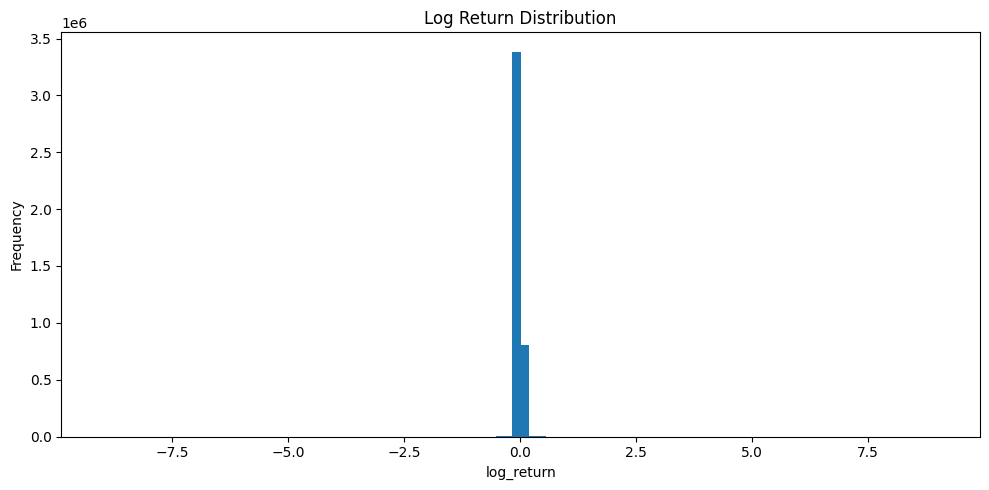

In [5]:
import matplotlib.pyplot as plt

plots_dir = Path('reports/plots')
plots_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['log_return'].dropna(), bins=100)
ax.set_title('Log Return Distribution')
ax.set_xlabel('log_return')
ax.set_ylabel('Frequency')
fig.tight_layout()
fig.savefig(plots_dir / 'phase3_log_return_distribution.png', dpi=150)
plt.show()

No AAPL rows for 2020 window in current dataset; plotting full available range instead.


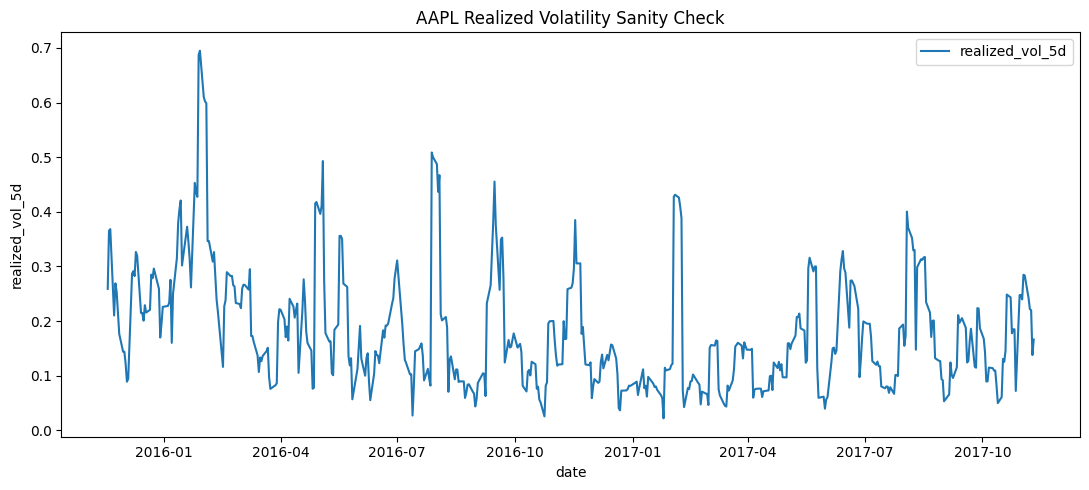

In [6]:
aapl_plot = df[df['ticker'] == 'AAPL'].sort_values('date').copy()
focus = aapl_plot[(aapl_plot['date'] >= pd.Timestamp('2020-01-01', tz='UTC')) & (aapl_plot['date'] <= pd.Timestamp('2020-06-30', tz='UTC'))]

if focus.empty:
    print('No AAPL rows for 2020 window in current dataset; plotting full available range instead.')
    focus = aapl_plot.tail(min(500, len(aapl_plot)))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(focus['date'], focus['realized_vol_5d'], label='realized_vol_5d')
ax.set_title('AAPL Realized Volatility Sanity Check')
ax.set_xlabel('date')
ax.set_ylabel('realized_vol_5d')
ax.legend()
fig.tight_layout()
fig.savefig(plots_dir / 'phase3_aapl_realized_volatility.png', dpi=150)
plt.show()

In [7]:
rsi_ok = ((df['rsi_14'].dropna() >= 0) & (df['rsi_14'].dropna() <= 100)).all()
print('RSI in [0, 100]:', bool(rsi_ok))

anti_leak_subset = df[df['target_start_date'].notna()].copy()
anti_leak_ok = (anti_leak_subset['date'] < anti_leak_subset['target_start_date']).all()
print('Anti-leakage check (feature_date < target_start_date):', bool(anti_leak_ok))

train_end = pd.to_datetime(config['dates']['train_end'], utc=True)
val_end = pd.to_datetime(config['dates']['validation_end'], utc=True)
train = df[df['date'] <= train_end]
val = df[(df['date'] > train_end) & (df['date'] <= val_end)]

if len(val) == 0:
    print('Validation split is empty for current data coverage; temporal split check skipped.')
else:
    print('Temporal split check:', bool(train['date'].max() < val['date'].min()))

RSI in [0, 100]: True
Anti-leakage check (feature_date < target_start_date): True
Validation split is empty for current data coverage; temporal split check skipped.


In [8]:
required_artifacts = [
    'datasets/features/price_features.parquet',
    'reports/timeseries_diagnostics.md',
    'reports/plots/phase3_log_return_distribution.png',
    'reports/plots/phase3_aapl_realized_volatility.png',
]

artifact_df = pd.DataFrame({'artifact': required_artifacts})
artifact_df['exists'] = artifact_df['artifact'].map(lambda p: Path(p).exists())
artifact_df

,artifact,exists
0,datasets/features/price_features.parquet,True
1,reports/timeseries_diagnostics.md,True
2,reports/plots/phase3_log_return_distribution.png,True
3,reports/plots/phase3_aapl_realized_volatility.png,True


In [9]:
from pathlib import Path

stocks_dir = Path('datasets/Data/Stocks')
sample_files = sorted(stocks_dir.glob('*.us.txt'))[:5]
for fp in sample_files:
    with fp.open('r', encoding='utf-8', errors='ignore') as f:
        lines = [line.strip() for line in f if line.strip()]
    first_data = lines[1] if len(lines) > 1 else 'N/A'
    last_data = lines[-1] if lines else 'N/A'
    print(fp.name, '| first:', first_data[:40], '| last:', last_data[:40])

a.us.txt | first: 1999-11-18,30.713,33.754,27.002,29.702,6 | last: 2017-11-10,67.35,67.58,66.7,66.81,170454
aa.us.txt | first: 1970-01-02,2.2972,2.3178,2.2972,2.2972,2 | last: 2017-11-10,42.93,44.46,42.75,43.01,44638
aaap.us.txt | first: 2015-11-11,18.5,25.9,18,24.5,1584600,0 | last: 2017-11-10,80.94,81.1,80.94,80.98,322441
aaba.us.txt | first: 1996-04-12,1.05,1.79,1.02,1.38,408720000 | last: 2017-11-10,70.6,70.745,69.94,70.56,44399
aac.us.txt | first: 2014-10-02,20,20.1,17.6,18.5,2799073,0 | last: 2017-11-10,10.9,11.4,10.735,11.28,143945


In [ ]:
from src.ingestion.price_loader import load_prices

load_prices(config)
prices_reingested = pd.read_parquet(config['paths']['interim_prices'])
print('Reingested rows:', len(prices_reingested))
print('Reingested tickers:', prices_reingested['ticker'].nunique())
print('Reingested date min:', prices_reingested['date'].min())
print('Reingested date max:', prices_reingested['date'].max())

Skipping file due to read error: accp.us.txt | No columns to parse from file
Skipping file due to read error: amrh.us.txt | No columns to parse from file
Skipping file due to read error: amrhw.us.txt | No columns to parse from file
Skipping file due to read error: asns.us.txt | No columns to parse from file
Skipping file due to read error: bbrx.us.txt | No columns to parse from file
Skipping file due to read error: bolt.us.txt | No columns to parse from file
Skipping file due to read error: boxl.us.txt | No columns to parse from file
Skipping file due to read error: bxg.us.txt | No columns to parse from file
Skipping file due to read error: ehr.us.txt | No columns to parse from file
Skipping file due to read error: fmax.us.txt | No columns to parse from file
Skipping file due to read error: gnst.us.txt | No columns to parse from file
Skipping file due to read error: hayu.us.txt | No columns to parse from file
Skipping file due to read error: jt.us.txt | No columns to parse from file
Sk